<a href="https://colab.research.google.com/github/jeosol/llm-post-training/blob/main/rlhf_from_scratch/2_Reward_Model_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Reward Model Training

In [1]:
# Set up the base moel
from transformers import AutoTokenizer
model_name = 'gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:86: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [4]:
%pip install datasets==3.5.0



## Load dataset

In [5]:
from datasets import load_dataset
dataset_name = 'sst2'
dataset = load_dataset(dataset_name)
dataset

DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})

In [6]:
# View the training and validation dataset
ds_train, ds_val = dataset['train'], dataset['validation']

In [7]:
ds_train[4]

{'idx': 4,
 'sentence': 'on the worst revenge-of-the-nerds clichés the filmmakers could dredge up ',
 'label': 0}

## Tokenize the dataset

In [8]:
REWARD_TOKEN_ID = tokenizer.eos_token_id

In [10]:
REWARD_TOKEN_ID

50256

In [30]:
text = ds_train[4]['sentence'] #"Hello, this is the first step of RLHF training."
print(text)
tokens = tokenizer(text)
print(tokens)
print(len(tokens['input_ids']))
print(tokenizer.decode(tokens['input_ids']))

on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 
{'input_ids': [261, 262, 5290, 15827, 12, 1659, 12, 1169, 12, 1008, 9310, 35478, 20954, 262, 28303, 714, 47478, 469, 510, 220], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}
20
on the worst revenge-of-the-nerds clichés the filmmakers could dredge up 


In [15]:
# Function to tokenize a batch
def tokenize(batch):
    outputs = tokenizer(batch['sentence']) # tokenizer returns a dict with keys 'input_ids' and 'attention_mask'
    # create new keys 'score' and 'score_index' for the length of the current batch
    outputs['score'] = [0] * len(outputs['input_ids'])
    outputs['score_index'] = [0] * len(outputs['input_ids'])

    # Loop over the batch
    for i in range(len(outputs['input_ids'])):
        outputs['input_ids'][i].append(REWARD_TOKEN_ID) # extend token array and add REWARD_TOKEN_ID, the eos_token_id
        outputs['attention_mask'][i].append(1) # set attention mask to 1,
        outputs['score'][i] = float(batch['label'][i]) # add the actual label (sentiment) for the data
        outputs['score_index'][i] = len(outputs['input_ids'][i]) - 1 # set the score index for the score,
    return outputs

map_kwargs = {
    "batched": True,
    "batch_size": 512,
    "remove_columns": ['idx', 'sentence', 'label'] # only keep the 'input_ids' and 'attention_mask' columns
}

# create the tokenized dataset
tokenized_dataset_train = ds_train.map(tokenize, **map_kwargs)
tokenized_dataset_val = ds_val.map(tokenize, **map_kwargs)

In [22]:
# view a sample tokenized dataset
tokenized_dataset_train[4]

{'input_ids': tensor([  261,   262,  5290, 15827,    12,  1659,    12,  1169,    12,  1008,
          9310, 35478, 20954,   262, 28303,   714, 47478,   469,   510,   220,
         50256]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 'score': tensor(0.),
 'score_index': tensor(20)}

In [23]:
# convert the tokenized dataset to tensors
tokenized_dataset_train.set_format(type='torch')
tokenized_dataset_val.set_format(type='torch')

In [18]:
tokenized_dataset_train[4]

{'input_ids': tensor([  261,   262,  5290, 15827,    12,  1659,    12,  1169,    12,  1008,
          9310, 35478, 20954,   262, 28303,   714, 47478,   469,   510,   220,
         50256]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
 'score': tensor(0.),
 'score_index': tensor(20)}

## Filter out shorter tweets

In [31]:
# include the extra column that holds the score
tokenized_dataset_train = tokenized_dataset_train.filter(lambda x: len(x['input_ids']) > 6)
tokenized_dataset_val = tokenized_dataset_val.filter(lambda x: len(x['input_ids']) > 6)

Filter:   0%|          | 0/49401 [00:00<?, ? examples/s]

Filter:   0%|          | 0/867 [00:00<?, ? examples/s]

In [32]:
len(tokenized_dataset_train)

49401

## LLM with Reward Head

In [34]:
import torch
from torch import nn
import numpy as np
from transformers import AutoModelForCausalLM

class RewardHead(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.hidden_size = config.hidden_size
        self.reward = nn.Linear(self.hidden_size, 1)
        self._post_init()

    # How the weights are initialized
    def _post_init(self):
        nn.init.normal_(self.reward.weight, std=(1.0 / np.sqrt(self.hidden_size + 1))) # how the weights are initialized
        nn.init.zeros_(self.reward.bias)

    def forward(self, hidden_states):
        return self.reward(hidden_states)

class GPT2RewardHead(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.llm = AutoModelForCausalLM.from_pretrained(model_name)
        self.reward_head = RewardHead(self.llm.config)

    def forward(self, input_ids, attention_mask):
        transformer_outputs = self.llm.forward(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )
        last_hidden_state = transformer_outputs.hidden_states[-1]
        reward = self.reward_head(last_hidden_state).squeeze(-1) # squeeze(-1) removes the last dimension of an array/tensor but only if that dimension has a size of 1
        return torch.sigmoid(reward)

# squeeze(-1) on (1,3,1) will change the shape to (1, 3)
# squeeze(0) on (1,5,4) will become (5,4), and squeeze(-1) is error

In [35]:
# Create a reward model
model = GPT2RewardHead(model_name)

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

### Create Dataset Loader

In [36]:
from torch.utils.data import DataLoader
from transformers import DataCollatorWithPadding

tokenizer.pad_token = tokenizer.eos_token

data_collator = DataCollatorWithPadding(tokenizer)

dataloader_params = {
    'batch_size': 64,
    'shuffle': True,
    'collate_fn': data_collator
}

# create the dataloaders
train_dataloader = DataLoader(tokenized_dataset_train, **dataloader_params)
val_dataloader = DataLoader(tokenized_dataset_val, **dataloader_params)

In [37]:
# View one batch of the data
batch = next(iter(train_dataloader))
print(batch.keys())

KeysView({'input_ids': tensor([[19188,   787,   340,  ..., 50256, 50256, 50256],
        [  272, 19992,   290,  ..., 50256, 50256, 50256],
        [10594,   761,   284,  ..., 50256, 50256, 50256],
        ...,
        [   79,  6629,   257,  ..., 50256, 50256, 50256],
        [ 4480, 14897, 14733,  ..., 50256, 50256, 50256],
        [ 7109,  1299,   465,  ..., 50256, 50256, 50256]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]]), 'score': tensor([1., 1., 0., 1., 1., 1., 1., 1., 0., 1., 0., 1., 0., 1., 1., 1., 0., 1.,
        1., 0., 0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 1., 1., 0., 0.,
        1., 0., 0., 0., 0., 1., 0., 1., 0., 1., 0., 1., 1., 0., 0., 0., 1., 0.,
        0., 0., 1., 1., 1., 0., 1., 1., 0., 0.]), 'score_index': tensor([18,  7, 12, 13, 14,  7, 12, 14, 13, 11, 15, 16,  9,  9,

In [38]:
print(batch['input_ids'][1])
print(batch['attention_mask'][1])
print(batch['score'][1])
print(batch['score_index'][1])

tensor([  272, 19992,   290, 49822,  2636,  6839,   220, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256])
tensor([1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])
tensor(1.)
tensor(7)


In [40]:
print(tokenizer.decode(batch['input_ids'][4]))

life that 's very different from our own and yet instantly recognizable <|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|><|endoftext|>


In [43]:
batch['attention_mask'][1].nonzero()[-1] # get nonzero indices and return the last one

tensor([7])

In [42]:
batch['attention_mask'][1].nonzero() # torch.nonzero() identifies and returns the indices of all non-zero elements within an input tensor

tensor([[0],
        [1],
        [2],
        [3],
        [4],
        [5],
        [6],
        [7]])

In [44]:
outputs = model(batch['input_ids'], batch['attention_mask'])

In [45]:
print(outputs.shape)

torch.Size([64, 46])


## Training Config

In [50]:
import torch
import matplotlib.pyplot as plt

#optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
# train for one complete pass of the entire training dataset through the neural network including the both forward and bcakward passes to update model parameters.
num_epochs = 1

# Initialize the storage
batch_losses = []
val_losses = []

In [46]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
criterion = nn.BCELoss()
num_epochs = 1 # N+ Implementation Detail paper

In [48]:
def validate():
    model.eval()
    total_loss = 0
    for i, batch in enumerate(val_dataloader):
        inputs = batch.to(device)
        model_inputs = {
            'input_ids': inputs['input_ids'],
            'attention_mask': inputs['attention_mask']
        }
        # inference/evaluation - just prediction from the model
        with torch.no_grad():  # torch.no_grad() is a context-manager (or decorator with @torch.no_grad()) that disables the gradient calculation (benefits: reduced memory usage, faster computation (skipping the overhead of tracking and graph-building), prevents "cuda out of memory")
            scores = model(**model_inputs)
            batch_indices = torch.arange(scores.shape[0])
            score = scores[batch_indices, inputs['score_index']]
            target = inputs['score']
            loss = criterion(score, target)
        total_loss += loss.item()
    print('validation loss:', total_loss / len(val_dataloader))

### Training Loop

In [ ]:
# torch.no_grad() - deactivates the gradient engine globally within it's scope to save memory
# model.eval() - only changes the behavior of specific layers like Dropout (turns it off) and Batch Normalization (uses learned statistics)

validation loss: 0.5355237913983208
Batch: 1, Loss: 0.6760843396186829
Batch: 2, Loss: 0.6132674217224121
Batch: 3, Loss: 0.49964970350265503
Batch: 4, Loss: 0.5223067998886108
Batch: 5, Loss: 0.446014940738678
Batch: 6, Loss: 0.3832230567932129
Batch: 7, Loss: 0.4658281207084656
Batch: 8, Loss: 0.6040518283843994
Batch: 9, Loss: 0.419634073972702
Batch: 10, Loss: 0.46279817819595337
Batch: 11, Loss: 0.4260232746601105
Batch: 12, Loss: 0.45496705174446106
Batch: 13, Loss: 0.43848350644111633
Batch: 14, Loss: 0.31145384907722473
Batch: 15, Loss: 0.36819177865982056
Batch: 16, Loss: 0.4240154027938843
Batch: 17, Loss: 0.4079778492450714
Batch: 18, Loss: 0.4537820518016815
Batch: 19, Loss: 0.27716004848480225
Batch: 20, Loss: 0.46864748001098633
Batch: 21, Loss: 0.3430573344230652
Batch: 22, Loss: 0.38936513662338257
Batch: 23, Loss: 0.3753695487976074
Batch: 24, Loss: 0.4909937381744385
Batch: 25, Loss: 0.3348589539527893
Batch: 26, Loss: 0.24684450030326843
Batch: 27, Loss: 0.3613837361

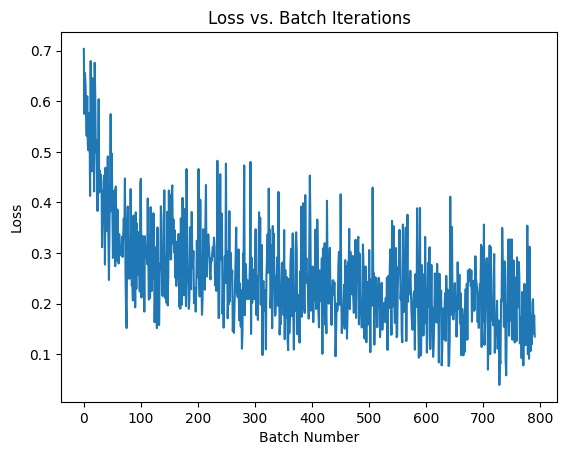

In [55]:
model.to(device)

validate()
for epoch in range(num_epochs):
    model.train()
    for i, batch in enumerate(train_dataloader):
        inputs = batch.to(device)
        model_inputs = {
            'input_ids': inputs['input_ids'],
            'attention_mask': inputs['attention_mask']
        }
        scores = model(**model_inputs)
        batch_indices = torch.arange(scores.shape[0])
        score = scores[batch_indices, inputs['score_index']]
        target = inputs['score']
        loss = criterion(score, target)
        print(f'Batch: {i+1}, Loss: {loss.item()}')
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Record the loss for this batch
        batch_losses.append(loss.item())

        #print(loss.item())
    validate()
#Smoothing: Plotting every single batch can result in noisy graph. For a clearer
# trend, you can plot the moving average or record the average loss every N batches

# Plot the Training Loss vs. Batch
plt.plot(batch_losses)
plt.xlabel('Batch Number')
plt.ylabel('Loss')
plt.title('Loss vs. Batch Iterations')
plt.show()

In [60]:
torch.save(model.state_dict(), 'reward_model.pt')

In [59]:
validate()

validation loss: 0.2865994657788958


### Confusion Matrix

In [62]:
# Get a confusion matrix for the validation dataset
from sklearn.metrics import confusion_matrix
model.eval()

all_predictions = []
all_labels = []

for i, batch in enumerate(val_dataloader):
    inputs = batch.to(device)
    model_inputs = {
        'input_ids': inputs['input_ids'],
        'attention_mask': inputs['attention_mask']
    }
    with torch.no_grad():
        scores = model(**model_inputs)
        batch_indices = torch.arange(scores.shape[0])
        score = scores[batch_indices, inputs['score_index']]
        target = inputs['score']
    predictions = (score > 0.5).int()

    all_predictions.extend(predictions.cpu().numpy())
    all_labels.extend(target.cpu().numpy())

confusion_matrix(all_labels, all_predictions)


array([[360,  64],
       [ 33, 410]])